# 03 · Other Statistical Tests

The A/B test used a two-proportion z-test. In everyday data work you meet many other situations: comparing two averages, the same people measured twice, two categorical variables, several groups, skewed data. This notebook is a practical tour of the tests used most often, each with:

- the question it answers
- the formula
- a tiny example worked by hand
- a short real example in Python
- the conclusion in plain words

**Tests covered**

1. Two-sample t-test (Student and Welch)
2. Paired t-test
3. Chi-square test of independence
4. One-way ANOVA (short version, full version in statistics notebook 09)
5. Correlation tests (Pearson and Spearman)
6. Mann-Whitney U test (non-parametric)
7. "Which test should I use?" decision table

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

## Datasets

| Dataset | Used for | Source |
|---|---|---|
| Tips (`data/tips.csv`) | t-test, ANOVA, correlation, Mann-Whitney | [seaborn-data](https://github.com/mwaskom/seaborn-data), Bryant & Smith (1995) |
| Sleep (`data/sleep.csv`) | Paired t-test | [Rdatasets](https://vincentarelbundock.github.io/Rdatasets/csv/datasets/sleep.csv), R's built-in `sleep` data, from Cushny & Peebles (1905), the data Student (Gosset) used in his 1908 t-test paper. Public domain |
| Titanic (`data/titanic.csv`) | Chi-square test of independence | [seaborn-data](https://github.com/mwaskom/seaborn-data) |
| Penguins (`data/penguins.csv`) | Two-sample t-test | [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/), CC0 |

**Sleep columns:** `extra` = extra hours of sleep compared with no drug, `group` = which of two sleeping drugs, `ID` = patient. The **same 10 patients** tried both drugs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

tips = pd.read_csv("../data/tips.csv")
tips["tip_percent"] = tips["tip"] / tips["total_bill"] * 100
sleep = pd.read_csv("../data/sleep.csv")
titanic = pd.read_csv("../data/titanic.csv")
penguins = pd.read_csv("../data/penguins.csv").dropna()

---
## 1. Two-sample t-test

**Question:** are the means of two **independent** groups different?

Examples: average order value of new vs returning customers, tip percentage of men vs women, test scores of two classes.

**Formula (Welch's t-test)**

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

The bottom is the standard error of the difference: it combines the uncertainty of both group means.

**Student vs Welch.** The original (Student's) t-test assumes both groups have the same variance. **Welch's** version doesn't. Welch is almost as good when the variances are equal and much safer when they are not, so many statisticians recommend using Welch by default. In scipy: `ttest_ind(a, b, equal_var=False)`.

Read more: Delacre, Lakens & Leys (2017), [Why Psychologists Should by Default Use Welch's t-test](https://doi.org/10.5334/irsp.82)

### Small example by hand

Delivery times (minutes) from two restaurants:

- A: 30, 32, 34, 36, 38 → mean 34, s² = 10
- B: 26, 28, 29, 31, 31 → mean 29, s² = 4.5

**By hand**

1. Difference of means = 34 − 29 = 5
2. SE = √(10/5 + 4.5/5) = √(2 + 0.9) = √2.9 = 1.703
3. t = 5 / 1.703 = **2.94**

In [2]:
a = np.array([30, 32, 34, 36, 38])
b = np.array([26, 28, 29, 31, 31])

se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
t_by_hand = (a.mean() - b.mean()) / se
print(f"variances: {a.var(ddof=1)}, {b.var(ddof=1)}")
print(f"t by hand = {t_by_hand:.3f}")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
print(stats.ttest_ind(a, b, equal_var=False))

variances: 10.0, 4.5
t by hand = 2.936
TtestResult(statistic=2.9361010975735176, pvalue=0.021856010245135005, df=6.993762993762993)


p ≈ 0.02 < 0.05 → restaurant A really is slower, even with only 5 deliveries each.

### Real example: do women and men tip a different percentage?

- H₀: mean tip % is the same for female and male payers
- H₁: it is different
- α = 0.05

In [3]:
female = tips.loc[tips["sex"] == "Female", "tip_percent"]
male = tips.loc[tips["sex"] == "Male", "tip_percent"]

print(f"female: n = {len(female)}, mean = {female.mean():.2f}%")
print(f"male  : n = {len(male)}, mean = {male.mean():.2f}%")

result = stats.ttest_ind(female, male, equal_var=False)
print(f"\nWelch t-test: t = {result.statistic:.2f}, p = {result.pvalue:.3f}")

female: n = 87, mean = 16.65%
male  : n = 157, mean = 15.77%

Welch t-test: t = 1.14, p = 0.254


**Conclusion:** p = 0.25 > 0.05 → no evidence of a difference. Women tipped 0.9 points more on average in this data, but that is well within normal random variation for groups of this size.

### Real example 2: are male penguins heavier?

In [4]:
adelie = penguins[penguins["species"] == "Adelie"]
male_mass = adelie.loc[adelie["sex"] == "MALE", "body_mass_g"]
female_mass = adelie.loc[adelie["sex"] == "FEMALE", "body_mass_g"]

result = stats.ttest_ind(male_mass, female_mass, equal_var=False)
print(f"male mean = {male_mass.mean():.0f} g, female mean = {female_mass.mean():.0f} g")
print(f"Welch t-test: t = {result.statistic:.1f}, p = {result.pvalue:.1e}")

male mean = 4043 g, female mean = 3369 g
Welch t-test: t = 13.1, p = 6.4e-26


**Conclusion:** p is tiny → male Adelie penguins are clearly heavier (by about 670 g).

---
## 2. Paired t-test

**Question:** did something change for the **same** subjects measured twice?

Examples: weight before and after a diet (same people), app speed before and after an update (same devices), the same patients trying two drugs.

> **The trick:** compute the difference for each subject, then run a **one-sample t-test** on those differences against 0.

**Formula**

$$d_i = x_{i,after} - x_{i,before}, \qquad t = \frac{\bar{d}}{s_d / \sqrt{n}}, \qquad df = n - 1$$

**Why pairing matters:** people are very different from each other (some sleep a lot, some little). Pairing removes those person-to-person differences, so the test only looks at the change. That gives much more power.

### The original Student data

10 patients each tried two sleeping drugs. `extra` = extra hours of sleep.

In [5]:
wide = sleep.pivot(index="ID", columns="group", values="extra")
wide.columns = ["drug_1", "drug_2"]
wide["difference"] = wide["drug_2"] - wide["drug_1"]
wide

,drug_1,drug_2,difference
ID,,,
1,0.7,1.9,1.2
2,-1.6,0.8,2.4
3,-0.2,1.1,1.3
4,-1.2,0.1,1.3
5,-0.1,-0.1,0.0
6,3.4,4.4,1.0
7,3.7,5.5,1.8
8,0.8,1.6,0.8
9,0.0,4.6,4.6


**By hand**

1. Differences: 1.2, 2.4, 1.3, 1.3, 0.0, 1.0, 1.8, 0.8, 4.6, 1.4
2. Mean difference $\bar{d}$ = 15.8 / 10 = **1.58** hours
3. Standard deviation of the differences $s_d$ = **1.23**
4. t = 1.58 / (1.23 / √10) = 1.58 / 0.389 = **4.06**, df = 9
5. Critical t (two-tailed, α = 0.05, df = 9) = 2.262 → 4.06 > 2.262 → $\color{red}{\textbf{reject } H_0}$

In [6]:
d = wide["difference"]
t_by_hand = d.mean() / (d.std() / np.sqrt(len(d)))
print(f"mean difference = {d.mean():.2f}, sd = {d.std():.2f}, t = {t_by_hand:.2f}")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html
print("paired t-test           :", stats.ttest_rel(wide["drug_2"], wide["drug_1"]))
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html
print("one-sample t-test on d  :", stats.ttest_1samp(d, 0))

mean difference = 1.58, sd = 1.23, t = 4.06
paired t-test           : TtestResult(statistic=4.062127683382037, pvalue=0.00283289019738427, df=9)
one-sample t-test on d  : TtestResult(statistic=4.062127683382037, pvalue=0.00283289019738427, df=9)


> **Check:** The paired t-test and the one-sample test on the differences are exactly the same thing.

### What if we forgot the pairing?

In [7]:
wrong = stats.ttest_ind(wide["drug_2"], wide["drug_1"])
print(f"Treating the groups as independent (WRONG): p = {wrong.pvalue:.3f}")
print(f"Paired test (RIGHT)                       : p = {stats.ttest_rel(wide['drug_2'], wide['drug_1']).pvalue:.3f}")

Treating the groups as independent (WRONG): p = 0.079
Paired test (RIGHT)                       : p = 0.003


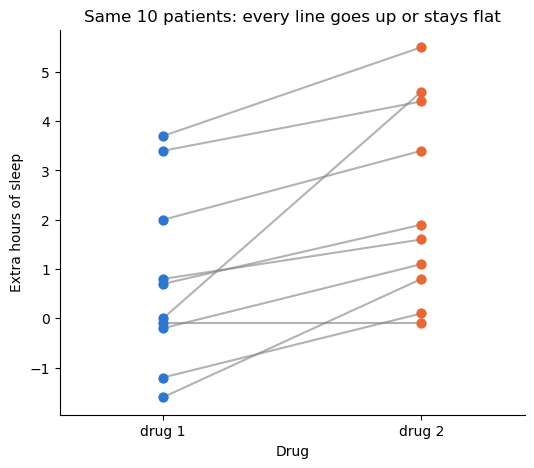

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for _, row in wide.iterrows():
    ax.plot([0, 1], [row["drug_1"], row["drug_2"]], color="grey", alpha=0.6, marker="o")
ax.scatter(np.zeros(10), wide["drug_1"], color=BLUE, zorder=3, s=40)
ax.scatter(np.ones(10), wide["drug_2"], color=ORANGE, zorder=3, s=40)
ax.set_xticks([0, 1])
ax.set_xticklabels(["drug 1", "drug 2"])
ax.set_xlim(-0.4, 1.4)
ax.set_title("Same 10 patients: every line goes up or stays flat")
ax.set_xlabel("Drug")
ax.set_ylabel("Extra hours of sleep")
plt.show()

Ignoring the pairing gives p = 0.08 (not significant). With pairing, p = 0.003. The chart shows why: the patients differ a lot from each other (the dots are spread vertically), but **every single line goes up or stays flat**. Pairing focuses on the lines, not the spread. Always use the paired test when the same subjects are measured twice.

---
## 3. Chi-square test of independence

**Question:** are two **categorical** variables related, or independent?

Examples: is device type related to purchase (yes/no)? Is ticket class related to survival? (Statistics notebook 06 covered the goodness-of-fit version, which checks one variable against expected shares.)

**Formula**

$$\chi^2 = \sum \frac{(O - E)^2}{E}, \qquad E = \frac{\text{row total} \times \text{column total}}{\text{grand total}}, \qquad df = (r - 1)(c - 1)$$

E is what each cell would contain if the two variables were completely independent.

### By hand: sex and survival on the Titanic

In [9]:
# docs: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html
observed = pd.crosstab(titanic["sex"], titanic["survived"], margins=True, margins_name="total")
observed.columns = ["died", "survived", "total"]
observed

,died,survived,total
sex,,,
female,81,233,314
male,468,109,577
total,549,342,891


**Expected counts if sex and survival were independent**

| | died | survived |
|---|---|---|
| female | 314 × 549 / 891 = **193.5** | 314 × 342 / 891 = **120.5** |
| male | 577 × 549 / 891 = **355.5** | 577 × 342 / 891 = **221.5** |

**Chi-square:**

$$\chi^2 = \frac{(81 - 193.5)^2}{193.5} + \frac{(233 - 120.5)^2}{120.5} + \frac{(468 - 355.5)^2}{355.5} + \frac{(109 - 221.5)^2}{221.5}$$
$$= 65.4 + 105.0 + 35.6 + 57.1 = \mathbf{263.1}$$

df = (2 − 1)(2 − 1) = 1 → critical value 3.84 → 263.1 is far beyond → $\color{red}{\textbf{reject } H_0}$: sex and survival were not independent.

In [10]:
table = pd.crosstab(titanic["sex"], titanic["survived"])
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html
chi2, p_value, dof, expected = stats.chi2_contingency(table, correction=False)

print("expected counts:\n", pd.DataFrame(expected, index=table.index, columns=["died", "survived"]).round(1))
print(f"\nchi-square = {chi2:.1f}, df = {dof}, p = {p_value:.1e}")

expected counts:
          died  survived
sex                    
female  193.5     120.5
male    355.5     221.5

chi-square = 263.1, df = 1, p = 3.7e-59


> **Note:** `correction=False` turns off Yates' continuity correction, so the result matches the hand formula. For 2×2 tables scipy applies the correction by default, which makes the test a little more conservative. With counts this large, it doesn't change the conclusion.

### How strong is the relationship? Cramér's V

χ² grows with the sample size, so it doesn't measure strength. **Cramér's V** scales it to 0-1:

$$V = \sqrt{\frac{\chi^2}{n \cdot (\min(r, c) - 1)}}$$

In [11]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print(f"Cramér's V, sex vs survival  : {cramers_v(table):.2f}")
print(f"Cramér's V, class vs survival: {cramers_v(pd.crosstab(titanic['class'], titanic['survived'])):.2f}")

Cramér's V, sex vs survival  : 0.54
Cramér's V, class vs survival: 0.34


Rough guide: 0.1 weak, 0.3 moderate, 0.5 strong. Sex (0.54) was more strongly linked to survival than ticket class (0.34).

### A "no relationship" example: smokers and lunch/dinner

In [12]:
table = pd.crosstab(tips["smoker"], tips["time"])
chi2, p_value, dof, expected = stats.chi2_contingency(table, correction=False)
print(table)
print(f"\nchi-square = {chi2:.2f}, p = {p_value:.2f}")

time    Dinner  Lunch
smoker               
No         106     45
Yes         70     23

chi-square = 0.74, p = 0.39


p = 0.39 → no evidence that the share of smoking tables differs between lunch and dinner.

---
## 4. One-way ANOVA (short version)

**Question:** do **three or more** groups have the same mean? The full explanation, with every step by hand, is in statistics notebook 09. Here is a quick real example.

In [13]:
day_order = ["Thur", "Fri", "Sat", "Sun"]
bills_by_day = [tips.loc[tips["day"] == day, "total_bill"] for day in day_order]

print(tips.groupby("day")["total_bill"].agg(["count", "mean"]).reindex(day_order).round(2))
print()
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
print("ANOVA         :", stats.f_oneway(*bills_by_day))
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
print("Kruskal-Wallis:", stats.kruskal(*bills_by_day))

      count   mean
day               
Thur     62  17.68
Fri      19  17.15
Sat      87  20.44
Sun      76  21.41

ANOVA         : F_onewayResult(statistic=2.7674794432863363, pvalue=0.04245383328952047)
Kruskal-Wallis: KruskalResult(statistic=10.403076391437086, pvalue=0.01543300820104127)


In [14]:
# docs: https://www.statsmodels.org/stable/generated/statsmodels.stats.multicomp.pairwise_tukeyhsd.html
tukey = pairwise_tukeyhsd(tips["total_bill"], tips["day"])
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Fri    Sat   3.2898 0.4541 -2.4799  9.0595  False
   Fri    Sun   4.2584 0.2371 -1.5856 10.1025  False
   Fri   Thur   0.5312 0.9957 -5.4434  6.5057  False
   Sat    Sun   0.9686 0.8968 -2.6088   4.546  False
   Sat   Thur  -2.7586 0.2374 -6.5455  1.0282  False
   Sun   Thur  -3.7273 0.0668 -7.6264  0.1719  False
----------------------------------------------------


**Conclusion:** the ANOVA is just significant (p = 0.042): average bills differ somewhere across the days. Bills are skewed, so the rank-based Kruskal-Wallis test is a good backup, and it agrees (p = 0.015).

The Tukey post-hoc table is a good reminder of how these tests work together. No single pair crosses the line on its own once we correct for 6 comparisons (Thursday vs Sunday comes closest, p ≈ 0.06), even though the overall test is significant. This happens with borderline results: the overall test pools all the evidence, while the pairwise tests each use only part of it. The honest summary: **weekend bills seem higher than Thursday bills, but the evidence is weak.**

---
## 5. Correlation tests

**Question:** is the correlation between two numeric variables different from 0?

**Formula** (for Pearson's r)

$$t = \frac{r\sqrt{n - 2}}{\sqrt{1 - r^2}}, \qquad df = n - 2$$

### Bigger bill, bigger tip?

**By hand:** r = 0.676, n = 244

$$t = \frac{0.676 \times \sqrt{242}}{\sqrt{1 - 0.676^2}} = \frac{0.676 \times 15.56}{0.737} = 14.26$$

With df = 242, a t of 14 is enormous → p is essentially 0.

In [15]:
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
r, p_pearson = stats.pearsonr(tips["total_bill"], tips["tip"])
n = len(tips)
t_by_hand = r * np.sqrt(n - 2) / np.sqrt(1 - r ** 2)

# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
rho, p_spearman = stats.spearmanr(tips["total_bill"], tips["tip"])

print(f"Pearson  r   = {r:.3f}, t by hand = {t_by_hand:.2f}, p = {p_pearson:.1e}")
print(f"Spearman rho = {rho:.3f}, p = {p_spearman:.1e}")

Pearson  r   = 0.676, t by hand = 14.26, p = 6.7e-34
Spearman rho = 0.679, p = 2.5e-34


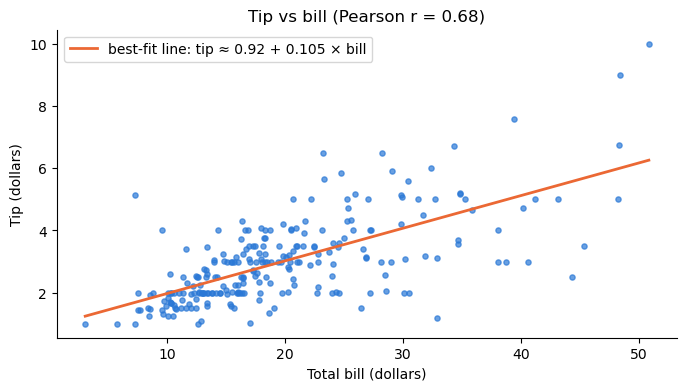

In [16]:
fig, ax = plt.subplots()
ax.scatter(tips["total_bill"], tips["tip"], s=14, color=BLUE, alpha=0.7)
slope, intercept = np.polyfit(tips["total_bill"], tips["tip"], 1)
x_line = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 100)
ax.plot(x_line, intercept + slope * x_line, color=ORANGE, linewidth=2, label=f"best-fit line: tip ≈ {intercept:.2f} + {slope:.3f} × bill")
ax.set_title(f"Tip vs bill (Pearson r = {r:.2f})")
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Tip (dollars)")
ax.legend()
plt.show()

**Conclusion:** a strong, clearly significant positive relationship. The slope of the line says each extra dollar on the bill comes with about 10.5 cents of extra tip, in line with tipping a percentage. Pearson and Spearman agree, so the relationship is not driven by a few outliers.

---
## 6. Mann-Whitney U test

**Question:** do two independent groups differ, when the data is **skewed, has outliers, or is ordinal** (like ratings 1-5)? It's the non-parametric alternative to the two-sample t-test. We used it for game rounds in the A/B test.

> **Idea:** forget the values, rank everything together, and check if one group's ranks are systematically higher. In plain words it answers: "if I take one random value from A and one from B, which one is likely to be bigger?"

**Formula**

$$U_A = R_A - \frac{n_A(n_A + 1)}{2}$$

$R_A$ = sum of the ranks of group A. $U_A$ is also simply **the number of (A, B) pairs where the A value is bigger**.

Read more: [Mann-Whitney U test (Wikipedia)](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test)

### By hand

Minutes spent on a page:

- A (old page): 2, 4, 7
- B (new page): 5, 8, 9, 11

Rank all 7 values together:

| value | 2 | 4 | 5 | 7 | 8 | 9 | 11 |
|---|---|---|---|---|---|---|---|
| group | A | A | B | A | B | B | B |
| rank | 1 | 2 | 3 | 4 | 5 | 6 | 7 |

- $R_A$ = 1 + 2 + 4 = 7
- $U_A$ = 7 − 3 × 4 / 2 = 7 − 6 = **1**

Check by counting pairs: the only (A, B) pair where A wins is 7 > 5. So **U_A = 1** out of 3 × 4 = 12 pairs. B wins 11 of the 12 comparisons.

In [17]:
group_a = [2, 4, 7]
group_b = [5, 8, 9, 11]

all_values = pd.Series(group_a + group_b)
ranks = all_values.rank()
rank_sum_a = ranks[:len(group_a)].sum()
u_a = rank_sum_a - len(group_a) * (len(group_a) + 1) / 2

pairs_a_wins = sum(1 for x in group_a for y in group_b if x > y)

print(f"rank sum of A = {rank_sum_a}, U_A = {u_a}, pairs where A wins = {pairs_a_wins}")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html
print(stats.mannwhitneyu(group_a, group_b, alternative="two-sided"))

rank sum of A = 7.0, U_A = 1.0, pairs where A wins = 1
MannwhitneyuResult(statistic=1.0, pvalue=0.11428571428571428)


With only 7 values the p-value is 0.11, so even though B wins 11 of 12 pairs, the sample is too small to be sure.

### Real example: do smokers' tables spend differently?

Bills are right-skewed, so Mann-Whitney is a natural choice. Let's compare it with the t-test.

In [18]:
smoker_bills = tips.loc[tips["smoker"] == "Yes", "total_bill"]
non_smoker_bills = tips.loc[tips["smoker"] == "No", "total_bill"]

print(f"smokers    : n = {len(smoker_bills)}, median = {smoker_bills.median():.2f}, mean = {smoker_bills.mean():.2f}")
print(f"non-smokers: n = {len(non_smoker_bills)}, median = {non_smoker_bills.median():.2f}, mean = {non_smoker_bills.mean():.2f}")

mw = stats.mannwhitneyu(smoker_bills, non_smoker_bills, alternative="two-sided")
welch = stats.ttest_ind(smoker_bills, non_smoker_bills, equal_var=False)
share_smoker_higher = mw.statistic / (len(smoker_bills) * len(non_smoker_bills))

print(f"\nMann-Whitney U: p = {mw.pvalue:.3f}  (a smoker's bill is higher in {share_smoker_higher:.0%} of all pairs)")
print(f"Welch t-test  : p = {welch.pvalue:.3f}")

smokers    : n = 93, median = 17.92, mean = 20.76
non-smokers: n = 151, median = 17.59, mean = 19.19

Mann-Whitney U: p = 0.341  (a smoker's bill is higher in 54% of all pairs)
Welch t-test  : p = 0.201


**Conclusion:** both tests say there is no clear difference (p > 0.05). In 54% of all smoker/non-smoker pairs the smoker's bill is higher, close to the 50% we would expect if there were no difference at all.

---
## 7. Which test should I use?

| What are you comparing? | Data type | Groups | Normal-ish data? | Test |
|---|---|---|---|---|
| One mean vs a known value | numeric | 1 | yes / large n | One-sample t-test (z-test if σ known) |
| One proportion vs a known value | yes / no | 1 | large n | One-proportion z-test |
| Counts vs expected shares | categories | 1 | expected ≥ 5 per cell | Chi-square goodness of fit |
| Two means, different subjects | numeric | 2 | yes / large n | **Welch's t-test** |
| Two groups, different subjects | numeric, skewed or ordinal | 2 | no | **Mann-Whitney U** |
| Same subjects measured twice | numeric | 2 (paired) | differences normal-ish | **Paired t-test** (or Wilcoxon signed-rank if not) |
| Two proportions (A/B conversion) | yes / no | 2 | large n | **Two-proportion z-test** (or chi-square) |
| Two categorical variables | categories | table | expected ≥ 5 per cell | **Chi-square test of independence** (Fisher's exact for tiny tables) |
| Three or more means | numeric | 3+ | yes | **One-way ANOVA** + Tukey post-hoc |
| Three or more groups | numeric, skewed or ordinal | 3+ | no | **Kruskal-Wallis** |
| Linear relationship | two numeric | - | roughly | **Pearson correlation test** |
| Monotonic relationship / outliers | two numeric or ordinal | - | no | **Spearman correlation test** |

Three questions are usually enough to pick a test:

1. **What type of data?** Numbers, yes/no, or categories?
2. **How many groups, and are they the same subjects or different ones?**
3. **Is the data roughly normal (or is the sample large)?** If not, use the rank-based version.

---
## Summary

| Test | Real example | Result |
|---|---|---|
| Welch t-test | Tip % women vs men | No difference (p = 0.25) |
| Welch t-test | Male vs female Adelie mass | Males heavier (p ≈ 0) |
| Paired t-test | Two sleeping drugs, same patients | Drug 2 better (p = 0.003). Unpaired would say p = 0.08 |
| Chi-square independence | Sex × survival (Titanic) | Strongly related (V = 0.54) |
| Chi-square independence | Smoker × lunch/dinner | Not related (p = 0.39) |
| ANOVA / Kruskal-Wallis | Bill by day | Weak evidence of a difference |
| Correlation test | Bill vs tip | Strong positive (r = 0.68) |
| Mann-Whitney U | Bills of smokers vs non-smokers | No difference |

## What's next

The **SQL folder** (`03_sql/`) gets numbers straight from a database: queries, joins, window functions, the A/B test metrics rebuilt in SQL, and the mistakes that give wrong answers without any error.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapters 6 and 7
- Student (1908), [The Probable Error of a Mean](https://doi.org/10.2307/2331554), Biometrika, the paper that introduced the t-test using the sleep data
- [Paired difference test](https://en.wikipedia.org/wiki/Paired_difference_test) · [Cramér's V](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V) (Wikipedia)
- [scipy.stats statistical tests overview](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests), a full list of tests with documentation